# Random Forest

In [178]:
import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns        # Statistical plotting


In [179]:
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Feacture Engineering

1) `Data Cleaning`

    - Handling Missing Values
    - Handling Duplicate Values
    - Check Data Type and Check Uniques count of Object
    - Understand the datasets

3) `Train test split`

4) `Train and Tes Datasets then Metrics`


### Check Data Type and Check Uniques count of Object

In [180]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [182]:
for col in df.columns:
    if df[col].dtype == "object":
        print("--------------------")
        print(f"{col}: {df[col].dtype}")
        print(df[col].value_counts())


--------------------
TypeofContact: object
TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64
--------------------
Occupation: object
Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64
--------------------
Gender: object
Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64
--------------------
ProductPitched: object
ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64
--------------------
MaritalStatus: object
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64
--------------------
Designation: object
Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64


In [183]:
df["Gender"].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [184]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [185]:
df["Gender"] = df["Gender"].replace("Fe Male", "Female")
df["MaritalStatus"] = df["MaritalStatus"].replace("Unmarried", "Single")


In [186]:
df["MaritalStatus"].value_counts()


MaritalStatus
Married     2340
Single      1598
Divorced     950
Name: count, dtype: int64

In [187]:
df["Gender"].value_counts()


Gender
Male      2916
Female    1972
Name: count, dtype: int64

### Handling Missing Values

        `Categorical Value` -> `Mode`

        `Numerical Feature` -> `Mean` and `Median`

In [188]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [189]:
# Filling missing values correctly
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)
df.Age.fillna(df.Age.median(), inplace=True)


C:\Users\sande\AppData\Local\Temp\ipykernel_6920\2851939609.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)
C:\Users\sande\AppData\Local\Temp\ipykernel_6920\2851939609.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [190]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [191]:
df.drop(columns=["CustomerID"], inplace=True)

In [192]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [193]:
df["TotalVisting"] = df["NumberOfPersonVisiting"] + df["NumberOfChildrenVisiting"]
df.drop(columns=["NumberOfChildrenVisiting","NumberOfPersonVisiting"], inplace=True)

In [194]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [195]:
# --- 1. Identify Categorical Columns ---
categorical_cols = [col for col in df.columns 
                    if df[col].dtype == "object" or str(df[col].dtype) == "category"]

# --- 2. Identify Numerical Columns ---
numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

# --- 3. Among numerical, separate Discrete and Continuous ---
discrete_cols = [col for col in numerical_cols if df[col].nunique() < 15]  # you can tweak threshold
continuous_cols = [col for col in numerical_cols if col not in discrete_cols]

# --- Print All ---
print("🔷 Categorical Features:", len(categorical_cols))
print("🔷 Numerical Features  :", len(numerical_cols))
print("🔷 Discrete Features   :", len(discrete_cols))
print("🔷 Continuous Features :", len(continuous_cols))


🔷 Categorical Features: 6
🔷 Numerical Features  : 12
🔷 Discrete Features   : 9
🔷 Continuous Features : 3


## Train Test Split

In [196]:
# df["MonthlyIncome"] = df["MonthlyIncome"]
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Single,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Single,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [197]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['ProdTaken'])
y = df['ProdTaken']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3910, 17), (3910,), (978, 17), (978,))

In [198]:
y.value_counts() # classfication probelems

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [199]:
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

print(cat_features)
print(num_features)


Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')
Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisting'],
      dtype='object')


In [200]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
ohe_tranformer = OneHotEncoder(drop="first")


preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", ohe_tranformer, cat_features),
        ("StandaradScaler", numeric_transformer, num_features)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test =preprocessor.transform(X_test)

X_train.shape, X_test.shape


((3910, 26), (978, 26))

## Training Classfiers (mulitple)

In [201]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


🔍 Model: AdaBoost on Test Data
✅ Accuracy       : 0.83640081799591
🎯 Precision      : 0.8283583060563965
📈 Recall         : 0.83640081799591
🧠 F1 Score       : 0.797683978346618
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.91       787
           1       0.78      0.23      0.35       191

    accuracy                           0.84       978
   macro avg       0.81      0.60      0.63       978
weighted avg       0.83      0.84      0.80       978



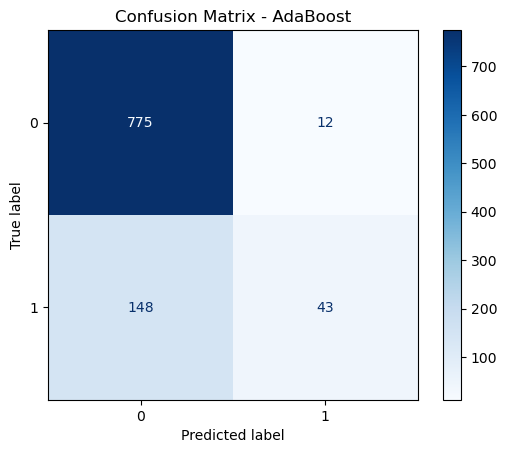

c:\Users\sande\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



🔍 Model: AdaBoostR on Test Data
✅ Accuracy       : 0.8333333333333334
🎯 Precision      : 0.8132034632034633
📈 Recall         : 0.8333333333333334
🧠 F1 Score       : 0.8111657945227564
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90       787
           1       0.64      0.33      0.44       191

    accuracy                           0.83       978
   macro avg       0.75      0.64      0.67       978
weighted avg       0.81      0.83      0.81       978



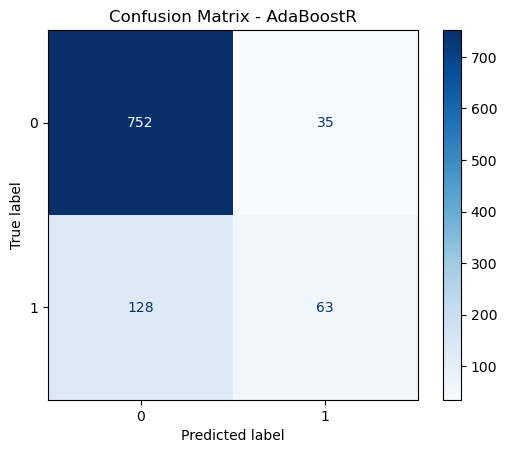


🔍 Model: DecisionTree on Test Data
✅ Accuracy       : 0.9161554192229039
🎯 Precision      : 0.9144780303045577
📈 Recall         : 0.9161554192229039
🧠 F1 Score       : 0.9151129699857449
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95       787
           1       0.80      0.75      0.78       191

    accuracy                           0.92       978
   macro avg       0.87      0.85      0.86       978
weighted avg       0.91      0.92      0.92       978



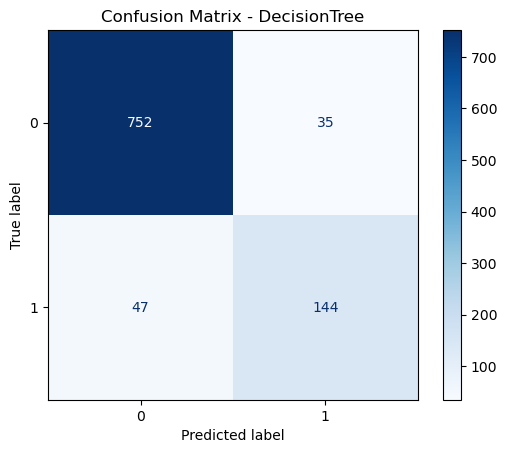


🔍 Model: LogisticsRegres on Test Data
✅ Accuracy       : 0.83640081799591
🎯 Precision      : 0.8186140763420632
📈 Recall         : 0.83640081799591
🧠 F1 Score       : 0.8086633047343356
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.90       787
           1       0.69      0.29      0.41       191

    accuracy                           0.84       978
   macro avg       0.77      0.63      0.66       978
weighted avg       0.82      0.84      0.81       978



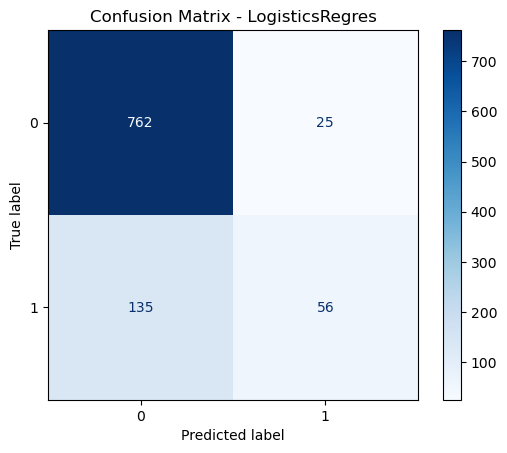


🔍 Model: RandomForest on Test Data
✅ Accuracy       : 0.9263803680981595
🎯 Precision      : 0.9295482980749183
📈 Recall         : 0.9263803680981595
🧠 F1 Score       : 0.9204103378197602
📊 Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96       787
           1       0.97      0.64      0.77       191

    accuracy                           0.93       978
   macro avg       0.94      0.82      0.86       978
weighted avg       0.93      0.93      0.92       978



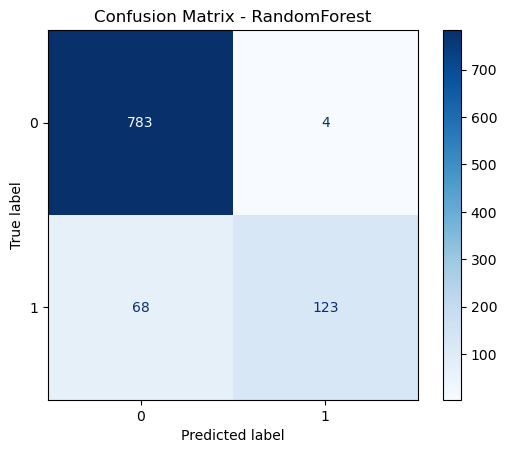

In [202]:
# 4. Train and evaluate
models = {
    "AdaBoost":AdaBoostClassifier(algorithm="SAMME", n_estimators=80),
    "AdaBoostR":AdaBoostClassifier(algorithm="SAMME.R",  n_estimators=80),
    "DecisionTree":DecisionTreeClassifier(),
    "LogisticsRegres": LogisticRegression(),
    "RandomForest": RandomForestClassifier(random_state=42)
}

# Dictionary to store metrics
model_scores = {}

# Loop through models
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Store scores
    model_scores[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    }

    # Print evaluation
    print(f"\n🔍 Model: {name} on Test Data")
    print("✅ Accuracy       :", acc)
    print("🎯 Precision      :", prec)
    print("📈 Recall         :", rec)
    print("🧠 F1 Score       :", f1)
    print("📊 Classification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


In [203]:
# Print sorted summary by Accuracy
print("\n📊 🔝 Sorted Model Performance (by Accuracy):")
import pandas as pd

results_df = pd.DataFrame(model_scores).T.sort_values(by="Accuracy", ascending=False)
print(results_df)


📊 🔝 Sorted Model Performance (by Accuracy):
                 Accuracy  Precision    Recall  F1 Score
RandomForest     0.926380   0.929548  0.926380  0.920410
DecisionTree     0.916155   0.914478  0.916155  0.915113
AdaBoost         0.836401   0.828358  0.836401  0.797684
LogisticsRegres  0.836401   0.818614  0.836401  0.808663
AdaBoostR        0.833333   0.813203  0.833333  0.811166
